# 3 - Results

This notebook evaluates the trained CNN model on the MNIST test set.
It covers the confusion matrix, classification report, and examples of incorrect predictions.

## 0 - Imports

In [29]:
import sys
import os

sys.path.append(os.path.join(os.path.abspath(""), "..", "src"))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model

from data_loader import load_data, preprocess_data

 ## 1 - Data and model loading

In [30]:
(X_train, y_train), (X_test, y_test) = load_data()
(X_train, y_train), (X_test, y_test) = preprocess_data(X_train, y_train, X_test, y_test)

model = load_model("../outputs/models/best_model.keras")
print("Model loaded successfully")

Model loaded successfully


## 2 - Accuracy on testing set

In [31]:
results = model.evaluate(X_test, y_test, verbose = 0)
test_loss, test_accuracy, test_precision, test_recall, test_auc = results

print(f"Test loss      : {test_loss:.4f}")
print(f"Test accuracy  : {test_accuracy:.4f}")
print(f"Test precision : {test_precision:.4f}")
print(f"Test recall    : {test_recall:.4f}")
print(f"Test AUC       : {test_auc:.4f}")

Test loss      : 0.0208
Test accuracy  : 0.9940
Test precision : 0.9948
Test recall    : 0.9939
Test AUC       : 0.9994


## 3 - Predictions

In [32]:
y_pred = model.predict(X_test)
y_pred_cls = np.argmax(y_pred,  axis = 1)
y_true_cls = np.argmax(y_test,  axis = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


## 4 - Classification

In [33]:
print(classification_report(y_true_cls, y_pred_cls))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      0.99      1135
           2       1.00      0.99      0.99      1032
           3       1.00      1.00      1.00      1010
           4       0.99      1.00      1.00       982
           5       1.00      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      1.00       974
           9       1.00      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## 5 - Confusion matrix

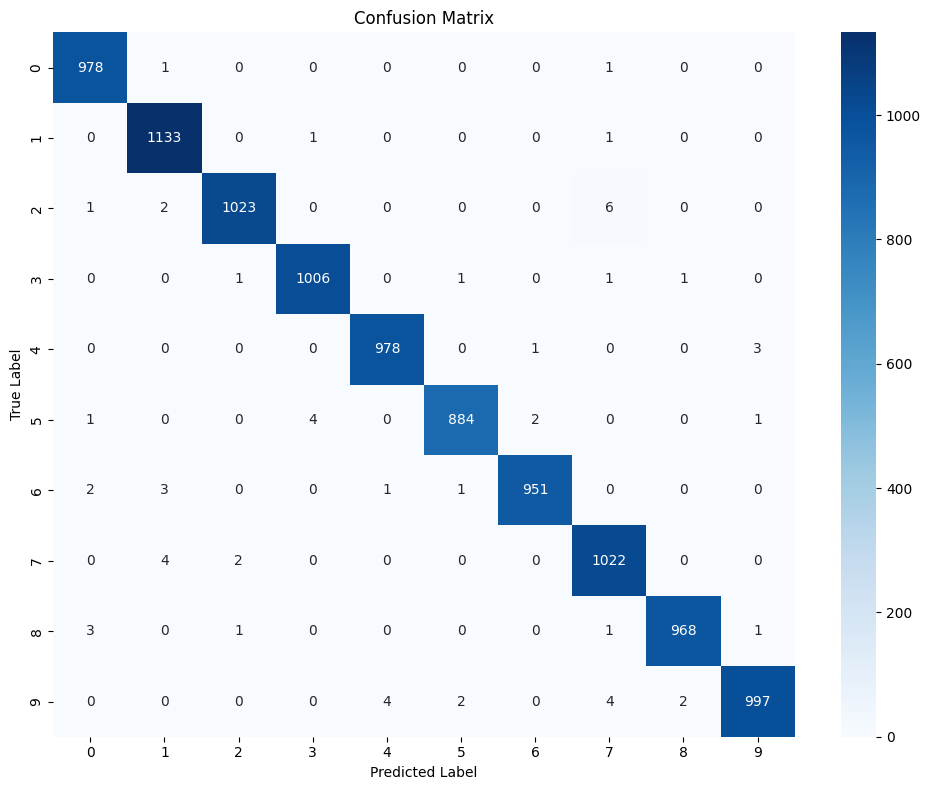

In [34]:
cm = confusion_matrix(y_true_cls, y_pred_cls)

plt.figure(figsize = (10, 8))
sns.heatmap(
    cm,
    annot = True,
    fmt = "d",
    cmap = "Blues",
    xticklabels = range(10),
    yticklabels = range(10)
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("../outputs/figures/confusion_matrix.png", dpi = 150)
plt.show()

## 6 - Incorrect predictions

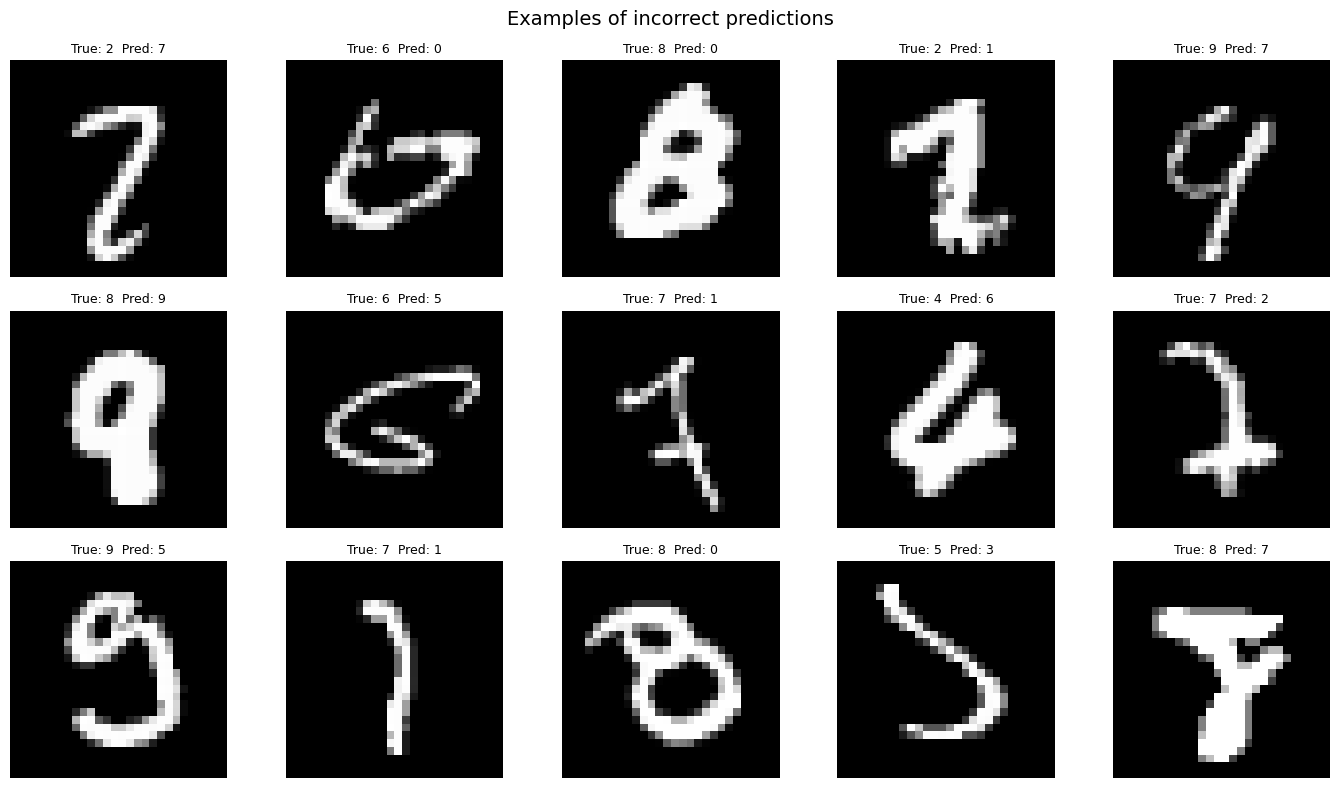

In [35]:
incorrect_idx = np.where(y_pred_cls != y_true_cls)[0]

fig, axes = plt.subplots(3, 5, figsize = (14, 8))
fig.suptitle("Examples of incorrect predictions", fontsize = 14)

for i, ax in enumerate(axes.flat):
    idx = incorrect_idx[i]
    ax.imshow(X_test[idx].reshape(28, 28), cmap = "gray")
    ax.set_title(f"True: {y_true_cls[idx]}  Pred: {y_pred_cls[idx]}", fontsize = 9)
    ax.axis("off")

plt.tight_layout()
plt.savefig("../outputs/figures/incorrect_predictions.png", dpi = 150)
plt.show()

## 7 - Single prediction

Correct prediction


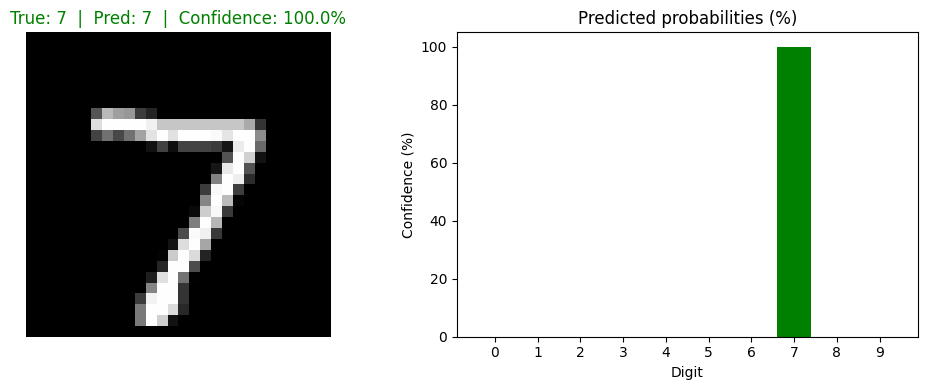

Incorrect prediction


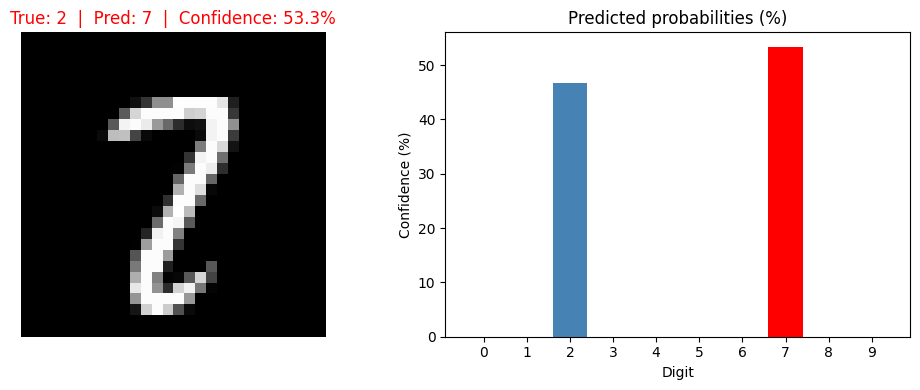

In [36]:
def plot_prediction(idx):
    image      = X_test[idx]
    true_label = y_true_cls[idx]
    pred_label = y_pred_cls[idx]
    confidence = y_pred[idx][pred_label] * 100
    is_correct = true_label == pred_label

    fig, axes = plt.subplots(1, 2, figsize = (10, 4))

    # Image
    axes[0].imshow(image.reshape(28, 28), cmap = "gray")
    color = "green" if is_correct else "red"
    axes[0].set_title(
        f"True: {true_label}  |  Pred: {pred_label}  |  Confidence: {confidence:.1f}%",
        color = color
    )
    axes[0].axis("off")

    # Probability bar chart
    axes[1].bar(range(10), y_pred[idx] * 100, color = "steelblue")
    axes[1].bar(pred_label, y_pred[idx][pred_label] * 100, color = color)
    axes[1].set_title("Predicted probabilities (%)")
    axes[1].set_xlabel("Digit")
    axes[1].set_ylabel("Confidence (%)")
    axes[1].set_xticks(range(10))

    plt.tight_layout()
    plt.show()

# Correct prediction
print("Correct prediction")
plot_prediction(0)

# Incorrect prediction
print("Incorrect prediction")
plot_prediction(incorrect_idx[0])